In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

BASE_URL = 'https://raw.githubusercontent.com/selaluar/Arya-Pratama-Hendri_2411533008_ML2526/main/Praktikum5'
TRAIN_URL = f'{BASE_URL}/train.csv'
TEST_URL = f'{BASE_URL}/test.csv'
GENDER_SUBMISSION_URL = f'{BASE_URL}/gender_submission.csv'

def load_csv_from_url_or_local(url, local_filename):
    """Membaca dataset dari URL GitHub. Jika gagal, baca dari file lokal."""
    try:
        df = pd.read_csv(url)
        print(f'Berhasil membaca {local_filename} dari GitHub')
        return df
    except Exception as e:
        print(f'Gagal membaca {local_filename} dari GitHub: {e}')
        print(f'Mencoba membaca file lokal: {local_filename}')
        return pd.read_csv(local_filename)

train_df = load_csv_from_url_or_local(TRAIN_URL, 'train.csv')
test_df = load_csv_from_url_or_local(TEST_URL, 'test.csv')
gender_submission_df = load_csv_from_url_or_local(GENDER_SUBMISSION_URL, 'gender_submission.csv')

print('Ukuran train_df:', train_df.shape)
print('Ukuran test_df:', test_df.shape)
print('Ukuran gender_submission_df:', gender_submission_df.shape)


Berhasil membaca train.csv dari GitHub
Berhasil membaca test.csv dari GitHub
Berhasil membaca gender_submission.csv dari GitHub
Ukuran train_df: (891, 12)
Ukuran test_df: (418, 11)
Ukuran gender_submission_df: (418, 2)


In [3]:

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Informasi kolom dan tipe data
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Mengecek jumlah missing value pada data training
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_train[missing_train > 0]


Cabin       687
Age         177
Embarked      2
dtype: int64

In [5]:

target_counts = train_df['Survived'].value_counts().sort_index()
target_percent = train_df['Survived'].value_counts(normalize=True).sort_index() * 100

distribusi_target = pd.DataFrame({
    'Jumlah': target_counts,
    'Persentase (%)': target_percent.round(2)
})
distribusi_target.index = ['Tidak Selamat (0)', 'Selamat (1)']
distribusi_target


,Jumlah,Persentase (%)
Tidak Selamat (0),549,61.62
Selamat (1),342,38.38


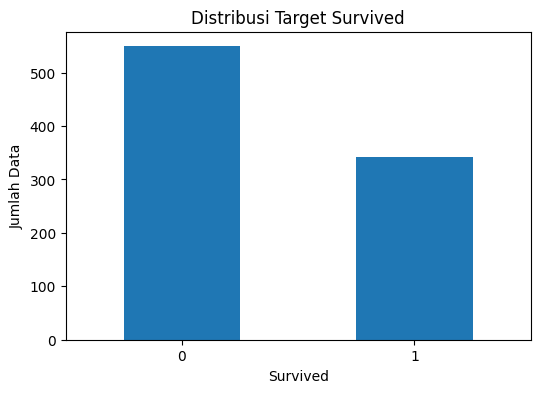

In [6]:

plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar')
plt.title('Distribusi Target Survived')
plt.xlabel('Survived')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()


In [7]:
def extract_title(name):
    """Mengambil gelar dari nama penumpang."""
    title = name.split(',')[1].split('.')[0].strip()
    title_mapping = {
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs',
        'Lady': 'Rare',
        'Countess': 'Rare',
        'Capt': 'Rare',
        'Col': 'Rare',
        'Don': 'Rare',
        'Dr': 'Rare',
        'Major': 'Rare',
        'Rev': 'Rare',
        'Sir': 'Rare',
        'Jonkheer': 'Rare',
        'Dona': 'Rare'
    }
    return title_mapping.get(title, title)

def feature_engineering(df):
    """Membuat fitur baru dari dataset Titanic."""
    data = df.copy()

    data['Title'] = data['Name'].apply(extract_title)
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    data['Deck'] = data['Cabin'].astype(str).str[0]
    data['Deck'] = data['Deck'].replace('n', 'Unknown')

    return data

train_fe = feature_engineering(train_df)
test_fe = feature_engineering(test_df)

# Fitur yang digunakan untuk model
feature_columns = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
    'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Deck'
]

X = train_fe[feature_columns]
y = train_fe['Survived']
X_test = test_fe[feature_columns]

print('Fitur yang digunakan:')
print(feature_columns)
print()
print('Ukuran X:', X.shape)
print('Ukuran y:', y.shape)
print('Ukuran X_test:', X_test.shape)


Fitur yang digunakan:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Deck']

Ukuran X: (891, 11)
Ukuran y: (891,)
Ukuran X_test: (418, 11)


In [8]:

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'Deck']


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare',
                                  'FamilySize']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked', 'Title',
                                  'IsAlone', 'Deck'])])

In [9]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )
}

# K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [10]:
def evaluate_model_with_kfold(model_name, model, X, y, skf):
    """Melatih dan mengevaluasi model menggunakan Stratified K-Fold."""
    fold_results = []
    oof_predictions = np.zeros(len(y), dtype=int)
    oof_probabilities = np.zeros(len(y), dtype=float)

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', clone(model))
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_valid)
        y_proba = pipeline.predict_proba(X_valid)[:, 1]

        oof_predictions[valid_idx] = y_pred
        oof_probabilities[valid_idx] = y_proba

        fold_results.append({
            'Model': model_name,
            'Fold': fold,
            'Accuracy': accuracy_score(y_valid, y_pred),
            'Precision': precision_score(y_valid, y_pred, zero_division=0),
            'Recall': recall_score(y_valid, y_pred, zero_division=0),
            'F1-Score': f1_score(y_valid, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_valid, y_proba)
        })

    return pd.DataFrame(fold_results), oof_predictions, oof_probabilities

all_fold_results = []
oof_data = {}

for model_name, model in models.items():
    result_df, oof_pred, oof_proba = evaluate_model_with_kfold(model_name, model, X, y, skf)
    all_fold_results.append(result_df)
    oof_data[model_name] = {
        'predictions': oof_pred,
        'probabilities': oof_proba
    }

fold_results_df = pd.concat(all_fold_results, ignore_index=True)
fold_results_df


,Model,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1,0.843575,0.805970,0.782609,0.794118,0.897826
1,Logistic Regression,2,0.825843,0.768116,0.779412,0.773723,0.870722
2,Logistic Regression,3,0.803371,0.770492,0.691176,0.728682,0.846725
3,Logistic Regression,4,0.831461,0.796875,0.750000,0.772727,0.852005
4,Logistic Regression,5,0.848315,0.800000,0.811594,0.805755,0.896623
5,Random Forest,1,0.837989,0.812500,0.753623,0.781955,0.901647
6,Random Forest,2,0.808989,0.783333,0.691176,0.734375,0.878008
7,Random Forest,3,0.831461,0.839286,0.691176,0.758065,0.834559
8,Random Forest,4,0.831461,0.806452,0.735294,0.769231,0.855214
9,Random Forest,5,0.837079,0.794118,0.782609,0.788321,0.888778


In [11]:

metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

summary_mean = fold_results_df.groupby('Model')[metric_columns].mean().add_suffix(' Mean')
summary_std = fold_results_df.groupby('Model')[metric_columns].std().add_suffix(' Std')
summary_df = pd.concat([summary_mean, summary_std], axis=1)

ordered_columns = []
for metric in metric_columns:
    ordered_columns.append(f'{metric} Mean')
    ordered_columns.append(f'{metric} Std')

summary_df = summary_df[ordered_columns].round(4)
summary_df


,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-Score Mean,F1-Score Std,ROC-AUC Mean,ROC-AUC Std
Model,,,,,,,,,,
Logistic Regression,0.8305,0.0177,0.7883,0.0177,0.7630,0.0457,0.7750,0.0294,0.8728,0.0240
Random Forest,0.8294,0.0118,0.8071,0.0212,0.7308,0.0399,0.7664,0.0214,0.8716,0.0268


<Figure size 1000x500 with 0 Axes>

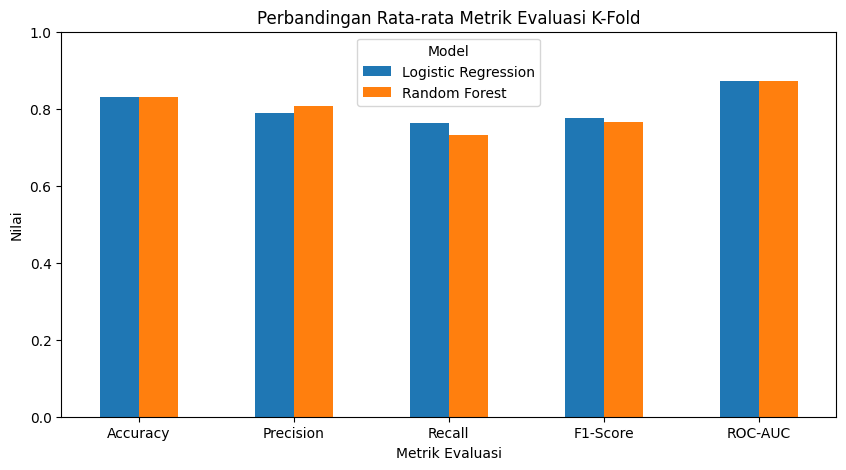

In [12]:

mean_metrics = fold_results_df.groupby('Model')[metric_columns].mean()

plt.figure(figsize=(10, 5))
mean_metrics.T.plot(kind='bar', figsize=(10, 5))
plt.title('Perbandingan Rata-rata Metrik Evaluasi K-Fold')
plt.xlabel('Metrik Evaluasi')
plt.ylabel('Nilai')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()


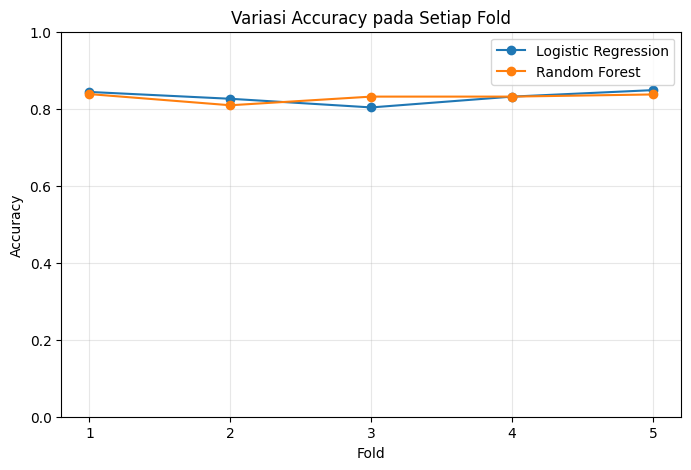

In [13]:

plt.figure(figsize=(8, 5))
for model_name in models.keys():
    model_result = fold_results_df[fold_results_df['Model'] == model_name]
    plt.plot(model_result['Fold'], model_result['Accuracy'], marker='o', label=model_name)

plt.title('Variasi Accuracy pada Setiap Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


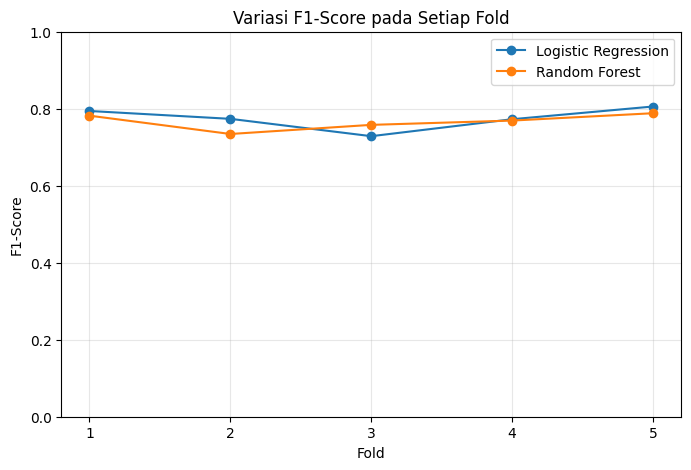

In [14]:

plt.figure(figsize=(8, 5))
for model_name in models.keys():
    model_result = fold_results_df[fold_results_df['Model'] == model_name]
    plt.plot(model_result['Fold'], model_result['F1-Score'], marker='o', label=model_name)

plt.title('Variasi F1-Score pada Setiap Fold')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [15]:

best_model_name = fold_results_df.groupby('Model')['F1-Score'].mean().idxmax()
best_model_name


'Logistic Regression'

In [16]:

best_oof_pred = oof_data[best_model_name]['predictions']
best_oof_proba = oof_data[best_model_name]['probabilities']

cm = confusion_matrix(y, best_oof_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Aktual Tidak Selamat (0)', 'Aktual Selamat (1)'],
    columns=['Prediksi Tidak Selamat (0)', 'Prediksi Selamat (1)']
)

print('Model terbaik berdasarkan rata-rata F1-Score:', best_model_name)
cm_df


Model terbaik berdasarkan rata-rata F1-Score: Logistic Regression


,Prediksi Tidak Selamat (0),Prediksi Selamat (1)
Aktual Tidak Selamat (0),479,70
Aktual Selamat (1),81,261


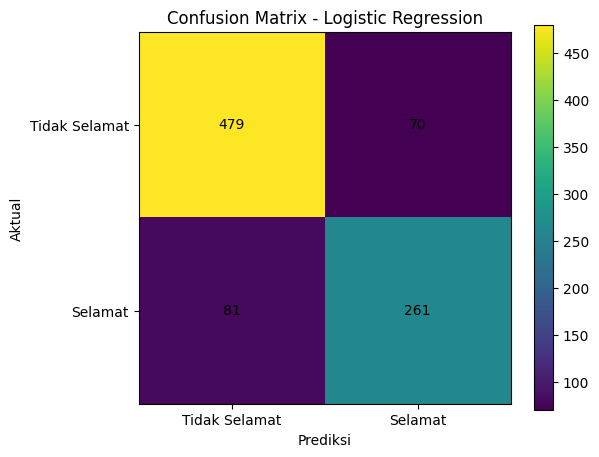

In [17]:

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.xticks([0, 1], ['Tidak Selamat', 'Selamat'])
plt.yticks([0, 1], ['Tidak Selamat', 'Selamat'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


In [19]:

print(f'Classification Report - {best_model_name}')
print(classification_report(y, best_oof_pred, zero_division=0))

print('ROC-AUC out-of-fold:', round(roc_auc_score(y, best_oof_proba), 4))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       549
           1       0.79      0.76      0.78       342

    accuracy                           0.83       891
   macro avg       0.82      0.82      0.82       891
weighted avg       0.83      0.83      0.83       891

ROC-AUC out-of-fold: 0.8708


In [20]:

best_summary = summary_df.loc[best_model_name]

print('KESIMPULAN HASIL K-FOLD CROSS VALIDATION')
print('-' * 55)
print(f'Model terbaik berdasarkan rata-rata F1-Score adalah: {best_model_name}')
print(f"Rata-rata Accuracy : {best_summary['Accuracy Mean']:.4f}")
print(f"Rata-rata Precision: {best_summary['Precision Mean']:.4f}")
print(f"Rata-rata Recall   : {best_summary['Recall Mean']:.4f}")
print(f"Rata-rata F1-Score : {best_summary['F1-Score Mean']:.4f}")
print(f"Rata-rata ROC-AUC  : {best_summary['ROC-AUC Mean']:.4f}")
print()
print('Pengaruh Cross Validation:')
print('1. Evaluasi model menjadi lebih stabil karena dilakukan pada 5 pembagian data berbeda.')
print('2. Semua data training pernah menjadi data validasi, sehingga hasil lebih representatif.')
print('3. Nilai standar deviasi menunjukkan variasi performa model antar-fold.')
print('4. Jika standar deviasi kecil, maka model cukup konsisten dan tidak terlalu bergantung pada satu pembagian data saja.')


KESIMPULAN HASIL K-FOLD CROSS VALIDATION
-------------------------------------------------------
Model terbaik berdasarkan rata-rata F1-Score adalah: Logistic Regression
Rata-rata Accuracy : 0.8305
Rata-rata Precision: 0.7883
Rata-rata Recall   : 0.7630
Rata-rata F1-Score : 0.7750
Rata-rata ROC-AUC  : 0.8728

Pengaruh Cross Validation:
1. Evaluasi model menjadi lebih stabil karena dilakukan pada 5 pembagian data berbeda.
2. Semua data training pernah menjadi data validasi, sehingga hasil lebih representatif.
3. Nilai standar deviasi menunjukkan variasi performa model antar-fold.
4. Jika standar deviasi kecil, maka model cukup konsisten dan tidak terlalu bergantung pada satu pembagian data saja.


In [21]:

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', clone(models[best_model_name]))
])

final_model.fit(X, y)

# Prediksi data test
test_predictions = final_model.predict(X_test)

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions.astype(int)
})

submission_df.head()


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [22]:
# Menyimpan hasil prediksi ke file CSV
submission_filename = 'submission_cross_validation.csv'
submission_df.to_csv(submission_filename, index=False)
print(f'File prediksi berhasil disimpan dengan nama: {submission_filename}')
print('Ukuran file submission:', submission_df.shape)


File prediksi berhasil disimpan dengan nama: submission_cross_validation.csv
Ukuran file submission: (418, 2)
